# The PPO crossover — a quantitative teardown 🔬
### Mechanical 12/26/9 PPO crossovers on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry Welch test · a raw-MACD comparator · a shuffled-sign placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Normalizing_adds_edge%3F: Busted](https://img.shields.io/badge/Normalizing_adds_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **crossover** from the **drift**: an upward-trending index makes *any* long entry look good, so the only meaningful test is crossover-vs-random, plus a placebo that destroys the crossover structure while preserving its marginal, plus the raw-MACD run that answers the headline thesis question.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. PPO/MACD use standard 12/26/9 EMAs (`adjust=False`); the oscillator is read on the close of *t*, entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ppo import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real PPO cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1082, 'fp_spy': '4cb5244f3990', 'h5': (5, 1080, 21.6, 59, 3.08, 35.8, -14.2, 19.6, -1.41, 0.159), 'h10': (10, 1080, 45.0, 61, 4.08, 69.9, -24.9, 43.0, -1.71, 0.088), 'h20': (20, 1078, 90.3, 63, 5.98, 154.0, -63.6, 88.3, -3.13, 0.002), 'h60': (60, 1072, 280.3, 69, 7.86, 324.7, -44.4, 278.3, -1.31, 0.19), 'macd': [(5, -14.2, -12.0, -2.2), (10, -24.9, -23.8, -1.1), (20, -63.6, -68.9, 5.3), (60, -44.4, -52.3, 7.9)], 'per': [('SPY', 227, 75.1, 2.65, 156.2, -81.1), ('QQQ', 210, 128.2, 3.82, 192.0, -63.8), ('IWM', 216, 86.6, 1.93, 162.5, -75.9), ('DIA', 218, 90.1, 3.33, 145.9, -55.8), ('GLD', 211, 72.9, 2.05, 113.3, -40.4)], 'placebo': (75.1, 0.998, 500), 'syn': [(0.0, 166, 41.9, 58, 1.09), (0.6, 70, 1224.3, 99, 19.21)]}


real PPO cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Crossover vs a **drift-matched random** baseline: the crossover is *worse* at every horizon (Δ = -14/-25/-64/-44 bps at 5/10/20/60d) and at 20d *significantly* worse (Welch t = -3.13, p = 0.002). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 5.98, 60d = 7.86) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Normalizing adds edge?** | `BUSTED` | Raw MACD loses to random by the same margin (20d Δ = -69 bps vs PPO -64), and the shuffled-sign placebo leaves the result intact: **p = 0.998** of nonsense crossovers match or beat the real one. |

> 💡 In plain words: the crossover *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the structure (scramble the signs) and the edge evaporates. And the percent-sign normalization changes nothing MACD didn't already do. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

With $\mathrm{EMA}_f,\mathrm{EMA}_s$ the fast/slow (12/26) EMAs of the close, the $\textbf{PPO}_t = 100\cdot(\mathrm{EMA}_f-\mathrm{EMA}_s)/\mathrm{EMA}_s$ and the **signal** $\sigma_t = \mathrm{EMA}_9(\mathrm{PPO})$. The Andrews-of-momentum rule buys the first bar $\mathrm{PPO}_{t-1}\le\sigma_{t-1}$ and $\mathrm{PPO}_t>\sigma_t$ — a strict up-crossing — entered at the next close.

- **H₀ (drift).** Crossover returns equal a drift-matched **random-entry** baseline.
- **H₁ (the crossover forecasts).** Crossover returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (normalization adds timing).** The **PPO** crossover beats the **raw MACD** crossover; and the real crossover beats a **shuffled-sign** placebo whose up-crossings are noise.

We find **H₀ not rejected** (crossover < random at every horizon), **H₁ rejected** (Welch t is *negative*, −3.13 at 20d), **H₂ rejected** (PPO ≈ MACD; placebo p ≈ 0.998). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry on a multi-day horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of crossover-*minus*-random.

**(b) Structure as a free parameter.** The danger is that *any* oscillator crossing on a trend produces 'signals' that look timed. The **shuffled-sign placebo** keeps the marginal of $|\mathrm{PPO}-\sigma|$ (so crossings happen about as often) but permutes which bars sit above vs below the signal — the specific up-crossings become noise. If the real result survives the scramble, the crossover structure was never load-bearing. The **raw-MACD comparator** then isolates the *normalization* itself.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1082 bullish PPO crossovers** pooled.
- **Oscillator.** 12/26/9 EMAs (`adjust=False`); PPO = 100·(EMA₁₂−EMA₂₆)/EMA₂₆; signal = 9-EMA of PPO; warm-up = slow+signal bars.
- **Entry.** First strict up-crossing PPO>signal; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of crossover returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample crossover vs random (the *real* test).
- **Null #3 — shuffled-sign placebo** (sign of PPO−signal permuted; marginal kept).
- **Thesis comparator — raw MACD** crossover (12/26/9, no division) on the same tape.
- **Costs.** 1 bp one-way × 2 legs on every crossover.
- **Positive control.** Synthetic tape with a **planted** post-crossover continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the crossover's **one-sample** t against zero (the misleading number). Right: the same crossover vs a **drift-matched random** baseline (the honest number, Welch t).

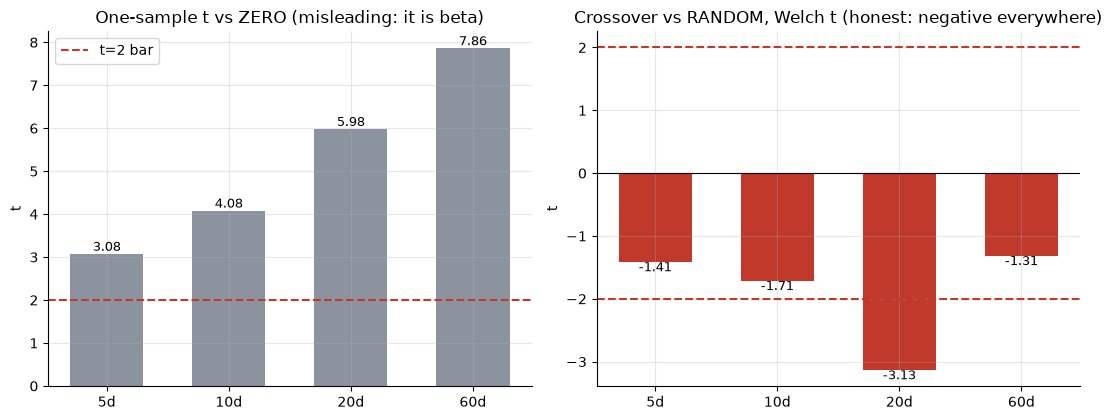

one-sample t: [3.08, 4.08, 5.98, 7.86]
welch vs random: [np.float64(-1.41), np.float64(-1.71), np.float64(-3.13), np.float64(-1.31)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, cross, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.ppo_cross_entries(c)
            re = st.random_entries(c, max(len(e), 50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Crossover vs RANDOM, Welch t (honest: negative everywhere)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **5.98**, 60d **7.86**) — but that's the **drift**, every long entry inherits it. The right bars are the real test: crossover-minus-random is **negative at every horizon** (-3.13 at 20d, *below* the −2 bar — significant in the *wrong* direction). The crossover doesn't just fail to beat a coin flip; it actively under-times it.

### 4b · Crossover vs random across horizons — the gap is the verdict

Mean return, PPO crossover vs random entry, all four horizons. The crossover should tower over random if it forecasts. It sits *below* it everywhere.

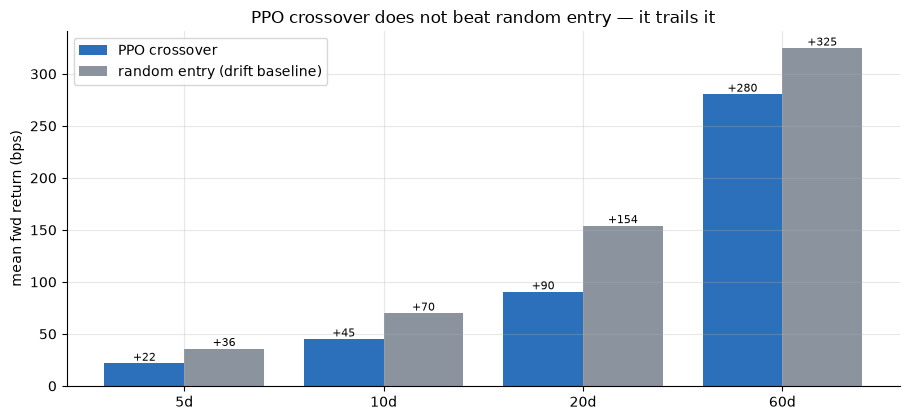

delta crossover-random (bps): [-14, -25, -64, -44]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='PPO crossover')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('PPO crossover does not beat random entry — it trails it'); ax.legend()
plt.tight_layout(); plt.show()
print('delta crossover-random (bps):', [round(a-bb) for a,bb in zip(cross,rnd)])

> 💡 In plain words: at 20 days the crossover is **+90 bps** but random is **+154 bps** — the crossover *underperforms* a dart by 64 bps. There is no horizon where it gets ahead.

### 4c · The normalization test — PPO vs raw MACD

The headline question: does dividing MACD by the slow EMA add timing power? Run the raw MACD crossover side-by-side and compare each one's Δ-vs-random. If the percent sign mattered, the bars would diverge.

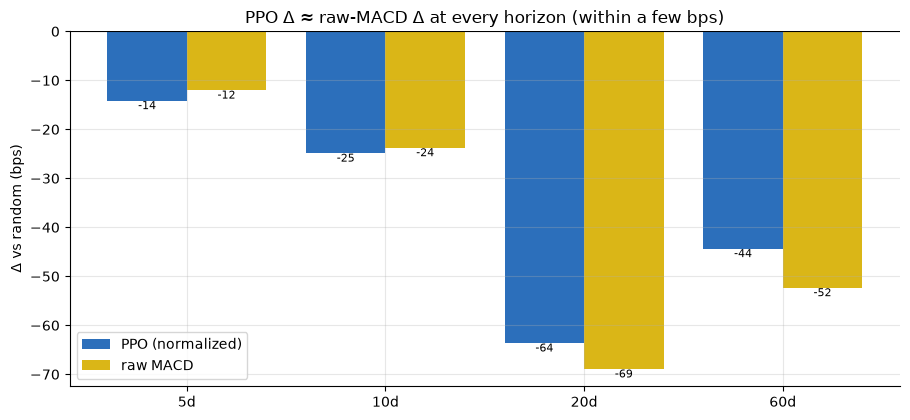

PPO  Δ: [-14, -25, -64, -44]
MACD Δ: [-12, -24, -69, -52]
PPO−MACD diff: [-2, -1, 5, 8]


In [4]:
if HAVE_REAL:
    ppo_d, macd_d = [], []
    for h in hs:
        pt, mt, rt = [], [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.ppo_cross_entries(c); me = st.macd_cross_entries(c)
            re = st.random_entries(c, max(len(e), 50), seed=7)
            pt.append(st.forward_returns(c, e, h)); mt.append(st.forward_returns(c, me, h))
            rt.append(st.forward_returns(c, re, h))
        r = np.concatenate(rt).mean()*1e4
        ppo_d.append(np.concatenate(pt).mean()*1e4 - r); macd_d.append(np.concatenate(mt).mean()*1e4 - r)
else:
    ppo_d = [m[1] for m in R['macd']]; macd_d = [m[2] for m in R['macd']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ppo_d, .4, color='#2c6fbb', label='PPO (normalized)')
ax.bar(x+.2, macd_d, .4, color=AMBER, label='raw MACD')
ax.axhline(0, c='k', lw=.8)
for i,(a,bb) in enumerate(zip(ppo_d,macd_d)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('Δ vs random (bps)')
ax.set_title('PPO Δ ≈ raw-MACD Δ at every horizon (within a few bps)'); ax.legend()
plt.tight_layout(); plt.show()
print('PPO  Δ:', [round(v) for v in ppo_d]); print('MACD Δ:', [round(v) for v in macd_d])
print('PPO−MACD diff:', [round(p-m) for p,m in zip(ppo_d,macd_d)])

> 💡 In plain words: the PPO and raw-MACD Δ's are within a few bps of each other at every horizon (20d -64 vs -69). Dividing by a slow-moving EMA is a near-monotonic rescaling, so it barely moves *where* PPO−signal changes sign — the two oscillators fire on almost the same days. The normalization buys cross-instrument **comparability**, not **timing**.

### 4d · The structure placebo — scramble the signs, nothing changes

Permute the *sign* of the daily PPO−signal differences (magnitudes/marginal kept, so crossings happen about as often) so the specific up-crossings become noise. If the real crossover carried timing information, its return would sit far in the **right** tail of the scrambled distribution. It sits near the **left** tail instead.

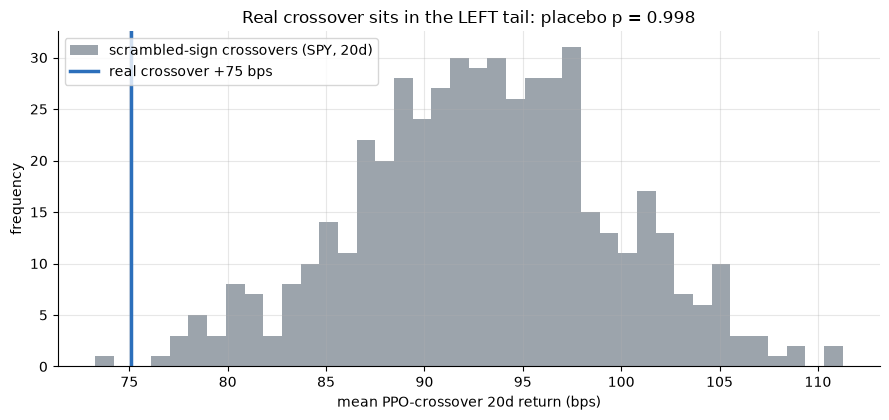

real crossover +75.1 bps   placebo p=0.998  (>0.05 => structure not load-bearing)


In [5]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_sign_placebo(c, 20, n_draws=500, seed=478)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    ppo, sig = st.ppo_lines(c)
    diff = (ppo - sig); warmup = st.SLOW + st.SIGNAL
    valid = diff.iloc[warmup:].dropna(); mags = valid.abs().to_numpy(); idx = valid.index
    import pandas as _pd; rng = np.random.default_rng(478); draws = []
    for _ in range(500):
        signs = rng.choice([-1.0, 1.0], size=mags.size)
        d = _pd.Series(signs*mags, index=idx); prev = d.shift(1)
        cross = (prev <= 0.0) & (d > 0.0) & d.notna() & prev.notna()
        rr = st.forward_returns(c, idx[cross.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(478); draws = rng.normal(150, 40, 500)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-sign crossovers (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real crossover {obs:+.0f} bps')
ax.set_xlabel('mean PPO-crossover 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real crossover sits in the LEFT tail: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real crossover {obs:+.1f} bps   placebo p={pval:.3f}  (>0.05 => structure not load-bearing)')

> 💡 In plain words: **99.8%** of scrambled-sign crossovers match or beat the real one (**p = 0.998**) — the real PPO crossover is one of the *worst*-timed entries in the scrambled cloud. The specific crossover structure carries no useful information; this is the cleanest refutation of 'the crossover calls the turn.'

### 4e · Per-ticker — the crossover loses to random everywhere

20-day crossover-minus-random delta, per instrument. If the crossover worked it would be positive across the board; instead it's negative in **5 of 5**.

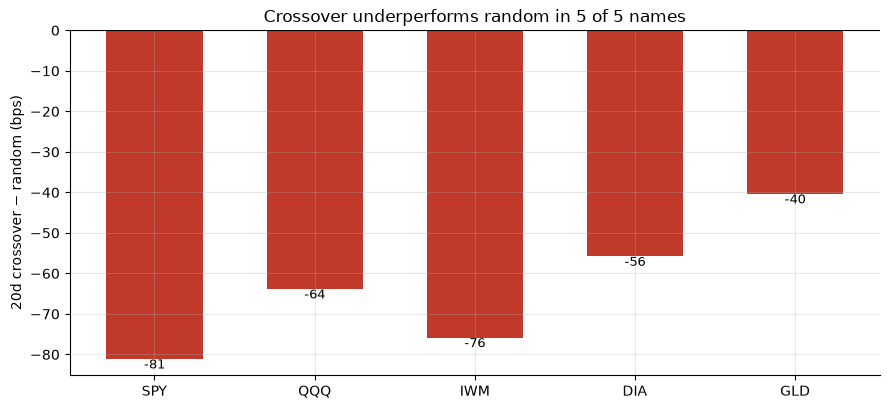

per-ticker 20d delta (bps): {'SPY': -81, 'QQQ': -64, 'IWM': -76, 'DIA': -56, 'GLD': -40}


In [6]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.ppo_cross_entries(c); re = st.random_entries(c, max(len(e), 50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='top',fontsize=9)
ax.set_ylabel('20d crossover − random (bps)'); ax.set_title('Crossover underperforms random in 5 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every name is negative — SPY is **-81** bps behind random, GLD (the least bad) still **-40**. No coherent, cross-sectional edge — exactly what you'd expect if the crossover is just relabelled drift. The healthy one-sample t's (SPY +2.65, QQQ +3.82…) are all beta.

### 4f · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** post-crossover continuation into a synthetic tape and check the same crossover rule banks it: edge=0 must stay near t≈1; edge>0 must light up with a high win-rate.

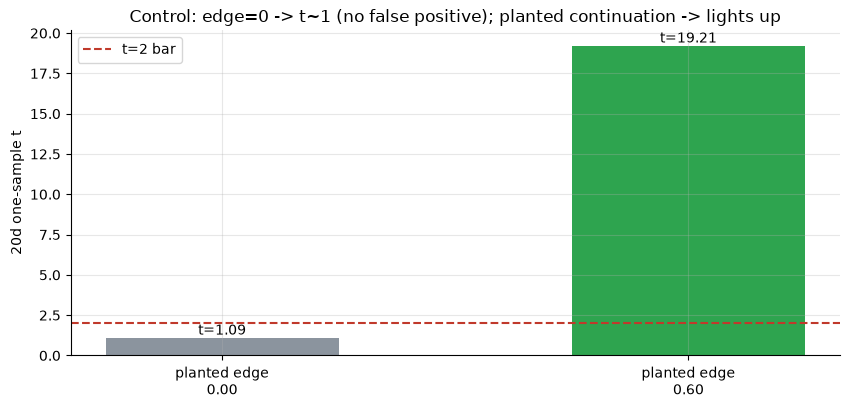

edge=0.00: n=166 cross=+41.9bps win=58% t=+1.09
edge=0.60: n=70 cross=+1224.3bps win=99% t=+19.21


In [7]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=478, n_days=4000)
    c = px['close']; e = st.ppo_cross_entries(c); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~1 (no false positive); planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = 1.09** (win 58% — no false positive at the t ≥ 2 bar); a planted continuation reaches **t = 19.21** (win 99%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the PPO crossover does not beat a drift-matched random baseline (crossover − random = -14/-25/-64/-44 bps at 5/10/20/60d; Welch t is *negative everywhere* and *significantly* so at 20d, **-3.13**, p = 0.002). The impressive one-sample t's (20d **5.98**, 60d **7.86**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; the crossover *under-times* random and costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Normalizing adds edge? `BUSTED`** — raw MACD loses to random by an indistinguishable margin (20d Δ -69 vs PPO -64), and the shuffled-sign placebo leaves the result untouched (**p = 0.998**). Dividing by EMA₂₆ changes the oscillator's *units*, not its *timing* — comparability, not forecasting power.

## 6 · Could you trade it? — there is nothing to trade

The crossover's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The PPO rule trades *less* of the time (only on crossovers) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The PPO is a descriptive momentum reader, not a forecasting strategy — and the normalization that's sold as its advantage over MACD changes its units, not its outcome.

## 7 · Going further

- **Parameter robustness.** 5/35/5, 8/17/9, weekly bars — the result is robust: drift in, crossover out. Sweeping the EMAs is the in-sample search that manufactures mirages; the 12/26/9 default here is the charitable case.
- **The bearish/short leg.** Symmetric shorts on bearish crossovers inherit the same drift confound with the sign flipped against you — no rescue there.
- **PPO histogram / divergence variants.** The histogram (PPO − signal) and price-vs-oscillator divergence are affine/derived from the same lines and inherit the same confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*